In [1]:
import os
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

In [2]:
def collect_Ts(folder_path):
    Ts = []

    for fname in tqdm(
        os.listdir(folder_path), desc=f"Scanning {os.path.basename(folder_path)}"
    ):
        if fname.endswith(".npy"):
            path = os.path.join(folder_path, fname)
            data = np.load(path)
            if data.shape[0]==1:
                print(path)
            Ts.append(data.shape[0])  # T

    return np.array(Ts)

In [3]:
datasets = {
    "XmoPipe": "XmoPipe/XmoPipe/new_joint_vecs",
    "HumanML3D": "HumanML3D/HumanML3D/new_joint_vecs",
    "Idea400": "Idea400/new_joint_vecs",
}
scale_factors = {
    "XmoPipe": 30,
    "HumanML3D": 20,
    "Idea400": 30,
}
T_data = {}

for name, path in datasets.items():
    Ts = collect_Ts(path)

    Ts = Ts / scale_factors[name]

    T_data[name] = {
        "Ts": Ts,
        "total_T": Ts.sum(),
        "num_files": len(Ts),
        "min": Ts.min(),
        "max": Ts.max(),
        "median": np.median(Ts),
    }

    print(f"{name}:")
    print(f"  fichiers : {len(Ts)}")
    print(f"  total T  : {Ts.sum():.1f}")
    print(
        f"  min / median / max : {Ts.min():.1f} / {np.median(Ts):.1f} / {Ts.max():.1f}"
    )

Scanning new_joint_vecs: 100%|██████████| 338843/338843 [04:03<00:00, 1392.11it/s]


XmoPipe:
  fichiers : 338843
  total T  : 2034258.8
  min / median / max : 0.1 / 4.1 / 21.7


Scanning new_joint_vecs:  46%|████▌     | 13311/29228 [00:08<00:10, 1571.84it/s]

HumanML3D/HumanML3D/new_joint_vecs/005836.npy


Scanning new_joint_vecs:  72%|███████▏  | 21154/29228 [00:13<00:05, 1600.86it/s]

...

HumanML3D/HumanML3D/new_joint_vecs/M000990.npy


Scanning new_joint_vecs: 100%|██████████| 29228/29228 [00:18<00:00, 1623.37it/s]


HumanML3D:
  fichiers : 29228
  total T  : 205869.6
  min / median / max : 0.1 / 7.5 / 23.4


Scanning new_joint_vecs: 100%|██████████| 12047/12047 [00:09<00:00, 1272.65it/s]

Idea400:
  fichiers : 12047
  total T  : 70316.8
  min / median / max : 0.2 / 5.8 / 16.1


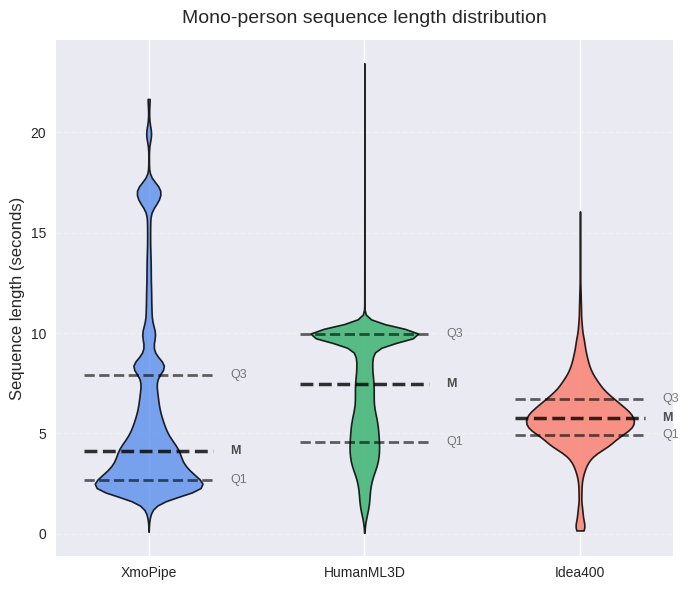

In [4]:

labels = list(T_data.keys())
data = [np.array(T_data[k]["Ts"]) for k in labels]

plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(figsize=(7, 6))

parts = ax.violinplot(
    data,
    showmeans=False,
    showmedians=False,
    showextrema=False,
)


colors = {
    "cornflowerblue",
    "salmon",
    "mediumseagreen",
}
for pc, color in zip(parts["bodies"], colors):
    pc.set_facecolor(color)
    pc.set_edgecolor("black")
    pc.set_alpha(0.85)
    pc.set_linewidth(1.2)
for i, d in enumerate(data, start=1):
    q1, med, q3 = np.percentile(d, [25, 50, 75])
    ax.hlines(
        [q1, q3],
        i - 0.3,
        i + 0.3,
        color="black",
        linewidth=2,
        linestyle="--",
        alpha=0.6,
        zorder=3,
    )
    ax.hlines(
        med,
        i - 0.3,
        i + 0.3,
        color="black",
        linewidth=2.5,
        linestyle="--",
        alpha=0.8,
        zorder=4,
    )
    x_text = i + 0.38
    ax.text(x_text, q1, "Q1", va="center", fontsize=9, alpha=0.6)
    ax.text(x_text, med, "M", va="center", fontsize=9, alpha=0.8, fontweight="bold")
    ax.text(x_text, q3, "Q3", va="center", fontsize=9, alpha=0.6)

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)

ax.set_ylabel("Sequence length (seconds)", fontsize=12)
ax.set_title("Mono-person sequence length distribution", fontsize=14, pad=12)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

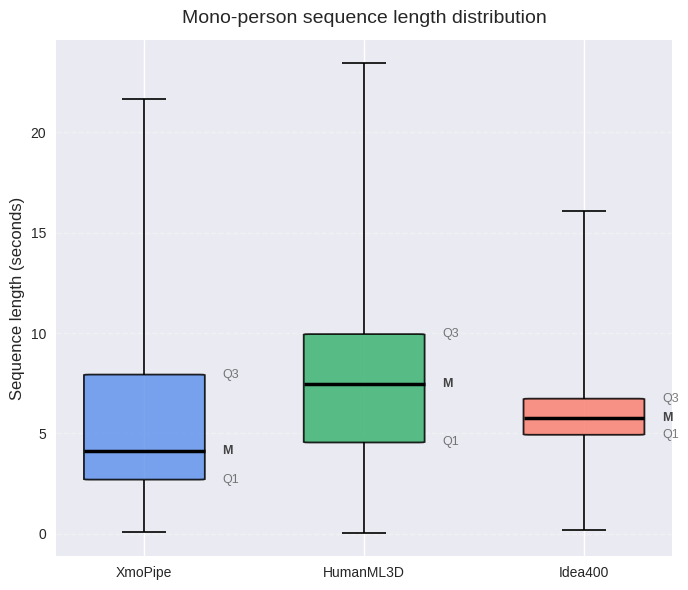

In [8]:
labels = list(T_data.keys())
data = [np.array(T_data[k]["Ts"]) for k in labels]

plt.style.use("seaborn-v0_8")
fig, ax = plt.subplots(figsize=(7, 6))
box_width = 0.55
for i, (d, color) in enumerate(zip(data, colors), start=1):
    q1, med, q3 = np.percentile(d, [25, 50, 75])
    wmin, wmax = np.min(d), np.max(d)
    rect = FancyBboxPatch(
        (i - box_width / 2, q1),
        box_width,
        q3 - q1,
        boxstyle="round,pad=0.0,rounding_size=0.025",
        facecolor=color,
        edgecolor="black",
        linewidth=1.3,
        alpha=0.85,
        zorder=2,
    )
    ax.add_patch(rect)
    ax.hlines(
        med,
        i - box_width / 2,
        i + box_width / 2,
        color="black",
        linewidth=2.5,
        zorder=3,
    )
    ax.vlines(i, wmin, q1, color="black", linewidth=1.2)
    ax.vlines(i, q3, wmax, color="black", linewidth=1.2)
    ax.hlines([wmin, wmax], i - 0.1, i + 0.1, color="black", linewidth=1.2)
    x_text = i + box_width / 2 + 0.08
    ax.text(x_text, q1, "Q1", va="center", fontsize=9, alpha=0.6)
    ax.text(x_text, med, "M", va="center", fontsize=9, alpha=0.85, fontweight="bold")
    ax.text(x_text, q3, "Q3", va="center", fontsize=9, alpha=0.6)

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)
ax.set_ylabel("Sequence length (seconds)", fontsize=12)
ax.set_title("Mono-person sequence length distribution", fontsize=14, pad=12)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()